<a href="https://colab.research.google.com/github/Munjiwon/SpecialTopics-in-TextMining/blob/master/ch03/negative_sampling_dist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3주차 실습 3 — 잡음 분포의 지수가 표집을 어떻게 바꾸나

**이 노트북의 새 개념**: P_n(w) ∝ U(w)^α 에서 α 를 1.0 / 0.75 / 0.5 로 바꿔 뽑히는 단어의 분포를 비교한다.

In [1]:
%pip install -q kiwipiepy

In [2]:
import sys, torch
print("Python", sys.version.split()[0], "| torch", torch.__version__, "| GPU:", torch.cuda.is_available())

Python 3.13.15 | torch 2.11.0+cpu | GPU: False


In [3]:
# 말뭉치 준비와 형태소 토큰화 — 1주차와 같은 Steam 리뷰 감성 말뭉치("레이블<TAB>텍스트")를 내려받고,
# 단어 임베딩 학습에는 문장만 쓰므로(레이블은 따로 보관만 한다) 한국어는 형태소 단위로 나눈다(2주차에서 본 것처럼 형태소 단위가 유리하다).
STEAM_URL = "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/steam.txt"
CORPUS_PATH = "data/steam.txt"  # code03/data/ 에 저장 (노트북 위치 기준 상대경로)
USE_OWN_CORPUS = False
if USE_OWN_CORPUS:
    from google.colab import files
    uploaded = files.upload()
    CORPUS_PATH = "/content/" + next(iter(uploaded))
else:
    import os, urllib.request
    os.makedirs(os.path.dirname(CORPUS_PATH), exist_ok=True)
    if not os.path.exists(CORPUS_PATH):  # 이미 내려받았으면 건너뜀
        urllib.request.urlretrieve(STEAM_URL, CORPUS_PATH)

# 파일 형식: 한 줄에 리뷰 하나, "레이블(0=부정, 1=긍정)<TAB>리뷰 문장"
lines, labels = [], []
with open(CORPUS_PATH, encoding="utf-8") as f:
    for line in f:
        label, text = line.rstrip("\n").split("\t", 1)   # 첫 탭을 기준으로 두 칸으로 나눔
        if text.strip():
            labels.append(int(label))
            lines.append(text.strip())
print(f"리뷰 {len(lines):,}개 (부정 {labels.count(0):,} / 긍정 {labels.count(1):,})")

from kiwipiepy import Kiwi
kiwi = Kiwi()
# 문장(줄) 하나를 토큰 목록 하나로 — gensim 과 직접 구현 모두 이 형태를 쓴다
sentences = [[t.form for t in kiwi.tokenize(l)] for l in lines]
print(f"문장 {len(sentences):,}개, 토큰 {sum(map(len, sentences)):,}개")

리뷰 100,000개 (부정 50,004 / 긍정 49,996)
문장 100,000개, 토큰 2,548,479개


α = 1.0   상위 100개 단어가 차지하는 비율 59.2%
α = 0.75  상위 100개 단어가 차지하는 비율 30.6%
α = 0.5   상위 100개 단어가 차지하는 비율 8.9%


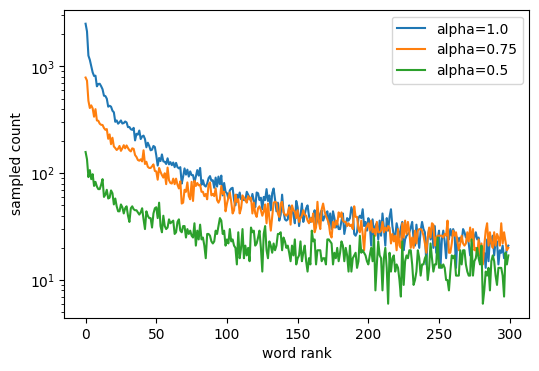

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(w for s in sentences for w in s)
vocab = [w for w, _ in counts.most_common()]
U = torch.tensor([counts[w] for w in vocab], dtype=torch.float)
U /= U.sum()

torch.manual_seed(0)
plt.figure(figsize=(6, 4))
for alpha in [1.0, 0.75, 0.5]:
    p = U ** alpha; p /= p.sum()
    draws = torch.multinomial(p, 50000, replacement=True)
    top100 = (draws < 100).float().mean().item()          # 상위 100 단어가 뽑힌 비율
    print(f"α = {alpha:<4}  상위 100개 단어가 차지하는 비율 {top100:.1%}")
    plt.plot(torch.bincount(draws, minlength=len(vocab))[:300].numpy(), label=f"alpha={alpha}")
plt.xlabel("word rank"); plt.ylabel("sampled count"); plt.yscale("log"); plt.legend()
plt.show()

## 서브샘플링 확률
P_drop(w) = 1 − √(t / f(w)) — 빈도 f 가 임계값 t 보다 훨씬 큰 단어일수록 자주 버린다.

In [5]:
t = 1e-3
for w in vocab[:5] + vocab[200:202]:
    f = counts[w] / sum(counts.values())
    p_drop = max(0.0, 1 - (t / f) ** 0.5)
    print(f"{w:<8} 상대빈도 {f:.4f}  버릴 확률 {p_drop:.2f}")

하        상대빈도 0.0498  버릴 확률 0.86
이        상대빈도 0.0429  버릴 확률 0.85
는        상대빈도 0.0246  버릴 확률 0.80
.        상대빈도 0.0227  버릴 확률 0.79
ᆫ        상대빈도 0.0197  버릴 확률 0.77
에게       상대빈도 0.0007  버릴 확률 0.00
같이       상대빈도 0.0007  버릴 확률 0.00


## 직접 해 보기
1. α = 0 이면 어떤 분포가 되는가? 학습 신호가 약해지는 이유를 설명해 보자.
2. t 를 1e-5 로 줄이면 어떤 단어까지 버려지는가?